# RSNA Knee Abnormality Detection

Local analysis notebook. Select the **Python (RSNA Knee)** kernel in the top-right before running cells.

Goal of this notebook: understand the **tables** before we touch images or models. An ML engineer’s first job is to map files onto the actual prediction problem.

In [80]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Working directory:", Path.cwd())

Python: 3.11.5
pandas: 3.0.5
Working directory: /Users/paramtully/IdeaProjects/TechnicalProjects/RSNA-Knee-Abnormality-Detection


In [141]:
DATA_DIR = Path(".")

train = pd.read_csv(DATA_DIR / "train.csv")
train_series = pd.read_csv(DATA_DIR / "train_series.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape)
print("train_series:", train_series.shape)
print("sample_submission:", sample_submission.shape)

train: (4407, 14)
train_series: (24371, 5)
sample_submission: (3, 13)


~4407 mri exams in train, joined to series (mri sequences) by the exam id

In [110]:
LABELS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]

# view the first few rows of the train dataframe
train.head()


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cónd...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231,Hallazgos:\nNo hay alteraciones en significativas de la médula ósea.\nLigamentos cruzados y colaterales dentro de lí...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274174707434356622764,"In the medial compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. \n The lat...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029415768216599146542,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAlignement articulaire :\nNormal.\n\nChangements dégénératifs :\nChondrop...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Findings:
- train consists of an id to map to mri sequences in series table, a written report (text) in several languages. remaining targets (they are the output we are predicting) are sparse.
- with further inspection, weak labels can be extracted from the report section

In [83]:
def schema(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "nunique": df.nunique(dropna=False), # tells us how many unique values are in the column
    })
display(schema(train))

# prove 58 complete rows in train data
nonNanRows = train[~train.isna().any(axis=1)]
print(f"{nonNanRows.shape[0]} complete rows in train data")

,dtype,non_null,nunique
StudyInstanceUID,str,4407,4407
Report,str,4407,4276
ACL,float64,58,3
MCL,float64,58,3
Medial Meniscus,float64,58,3
Lateral Meniscus,float64,58,3
Medial OA,float64,58,3
Lateral OA,float64,58,3
PF OA,float64,58,3
Effusion,float64,58,3


58 complete rows in train data


Findings:
    - 58 complete rows in train data
        - ie only 58 labelled targets
    - targets are binary or NaN ({0, 1, NaN})
    - there are repeat reports with unique ids

In [139]:
# Duplicate report texts: how many, and how often?
# duplicated(keep='first') drops the original row, so you only see copies 2..n.
# groupby().value_counts() defaults to dropna=True, which drops almost every
# unlabeled row (NaN in ACL/MCL/...) and can yield an empty table.
report_counts = train.groupby("Report").size()

dup_counts = pd.DataFrame(report_counts[report_counts > 1].sort_values(ascending=False))
display(dup_counts.head())

print(f"{dup_counts.shape[0]} report texts appear more than once")
print(f"{dup_counts.sum()[0] - dup_counts.shape[0]} studies share one of those texts") 


,0
Report,
Diz eklemi içi sıvı miktarı normal. Çapraz ve yan bağlar normal. Medyal ve lateral menisküs normal. Eklem kıkırdakları ve kemikler normal. Ekstensör mekanizma korunmuş. Proksimal tibyofibular eklem normal.,37
Técnica: RMN de la rodilla. Resultados: Pinzamiento de la almohadilla grasa de Hoffa. Impresión: Pinzamiento de la almohadilla grasa de Hoffa,14
Técnica: RMN de la rodilla. Resultados: Sin anomalías. Impresión: Sin anomalías,12
"FINDINGS:\n\nFluid:\nNo joint effusion. No popliteal cyst.\n\nMedial compartment (meniscus, collateral ligament, cartilage):\nNormal.\n\nLateral compartment (meniscus, collateral ligament complex, cartilage):\nNormal.\n\nIntercondylar compartment (anterior and posterior cruciate ligaments):\nNormal.\n\nAnterior compartment (extensor mechanism, cartilage, Hoffa's fat pad):\nNormal.\n\nBones:\nNormal.\n\nMuscles and neurovascular structures:\nNormal.\n\nOther findings:\nNone\n\nCONCLUSION:\nNo internal derangement of the knee ligaments or menisci is identified.",6
Técnica: RMN de la rodilla. Resultados: Sin anomalias. Impresión: Sin anomalias.,5


46 report texts appear more than once
131 studies share one of those texts


Findings:
- Something like: 46 exact report strings are reused across 177 studies (131 extras). They are short canned reports, mostly normals, not 177 unique long writeups that happened to match. At least one English template is truncated mid-word. Treat them as one silver label per unique string, not 177 independent labels.

In [84]:
# view the first few rows of the train_series dataframe
train_series.head()


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.13821229744997220641575291927426543265,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.23084836536722595275828690293168736174,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.40734206102458723096154687147390476697,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.75714899997203615784077798038670363546,0,0,Sagittal


only 3 meaningful datapoints per sequence type: fluid sensitivive, fat suppression, and anatomical plane

In [85]:
display(schema(train_series))

trainIds = train['StudyInstanceUID']
trainIdsInSeries = train_series['StudyInstanceUID']

# check if all train ids are in train_series and vise versa
print(all(trainIds.isin(trainIdsInSeries)))
print(all(trainIdsInSeries.isin(trainIds)))


,dtype,non_null,nunique
StudyInstanceUID,str,24371,4407
SeriesInstanceUID,str,24371,24371
Fluid_Sensitive,int64,24371,2
Fat_Suppression,int64,24371,2
Anatomical_Plane,str,24371,3


True
True


Findings:
- series are joined to the 4407 studies (proved by nunique and isIn checks)
- no duplicate series instances 
- all rows are fully populated
- Fluid_Sensitive, Fat_Suppression are both binary {0, 1} but stored as ints
- Anatomical_Plane can have 3 values {Sagittal, Axial, Coronal}

In [86]:
# look into what each study is composed of

# look at how many series are in each study
display(pd.DataFrame(train_series.groupby('StudyInstanceUID').size().describe()))

# look at the number of unique anatomical planes per study
display(pd.DataFrame(train_series.groupby('StudyInstanceUID')['Anatomical_Plane'].nunique().value_counts()))


,0
count,4407.000000
mean,5.530066
std,1.393826
min,3.000000
25%,5.000000
50%,5.000000
75%,6.000000
max,14.000000


,count
Anatomical_Plane,
3,4407


Findings:
- variable # series per study (3-14 from the train data)
- each study has at least one series per axis

In [88]:
# look at the correlation between fat suppression and fluid sensitive settings for images
display(pd.DataFrame(train_series["Anatomical_Plane"].value_counts()))
display(pd.crosstab(train_series["Fluid_Sensitive"], train_series["Fat_Suppression"]))

# look at the distribution of anatomical planes per study
display(pd.DataFrame(pd.crosstab(train_series["StudyInstanceUID"], train_series["Anatomical_Plane"]).value_counts()))


,count
Anatomical_Plane,
Sagittal,9864
Coronal,8609
Axial,5898


Fat_Suppression,0,1
Fluid_Sensitive,,
0,10361,0
1,0,14010


count
Axial Coronal Sagittal       
1     2       2          1785
      1       2           582
      3       2           307
2     1       2           262
1     1       3           233
...                       ...
2     4       5             1
      5       3             1
1     4       4             1
3     2       1             1
1     4       6             1

[71 rows x 1 columns]

Findings:
- Fat_Suppression and Fluid_Sensitive settings are directly correlated (always done together)
- 1 Axial and 2+ Sagittal are most common (>50%)

In [103]:
# dive deeper into non-null targets
print(f"{train[train.notna().all(axis=1)].shape[0]} studies with all targets present")

# look at the mean per label among labled studies
gold_studies = train[train.notna().all(axis=1)]
display(pd.DataFrame(gold_studies[LABELS].mean(), columns=['mean']))


58 studies with all targets present


,mean
ACL,0.413793
MCL,0.155172
Medial Meniscus,0.448276
Lateral Meniscus,0.396552
Medial OA,0.258621
Lateral OA,0.189655
PF OA,0.362069
Effusion,0.603448
Synovitis,0.465517
Baker's,0.206897


Findings:
- of the 58 targets, there is low representation for MCL, Lateral OA, and arguably Bakers, and Medial OA
conclusion: 58 gold rows arent sufficient to train

In [108]:
# look at sample submission layout vs train table
print(f"are all sample submission columns in train? {all(sample_submission.columns.isin(train.columns))}")

# look at the first few rows of the sample submission dataframe
display(sample_submission.dtypes)

# look at the first few rows of the train dataframe
display(train.dtypes)


are all sample submission columns in train? True


StudyInstanceUID        str
ACL                 float64
MCL                 float64
Medial Meniscus     float64
Lateral Meniscus    float64
Medial OA           float64
Lateral OA          float64
PF OA               float64
Effusion            float64
Synovitis           float64
Baker's             float64
Contusion           float64
Fracture            float64
dtype: object

StudyInstanceUID        str
Report                  str
ACL                 float64
MCL                 float64
Medial Meniscus     float64
Lateral Meniscus    float64
Medial OA           float64
Lateral OA          float64
PF OA               float64
Effusion            float64
Synovitis           float64
Baker's             float64
Contusion           float64
Fracture            float64
dtype: object

Findings:
    - train is int as a float while expected output is a float probability 

In [ ]:
# analyze the mri scans loaded locally
study_mri_folders = [f.name for f in Path(DATA_DIR / "train_series").glob("*")]
print(study_mri_folders)
studyId = study_mri_folders[0]

# match study and series with those in training set
study_row = train.loc[train['StudyInstanceUID'] == studyId]
display(study_row)

# find and match series in train_series
series_mri_folders = [f.name for f in Path(DATA_DIR / "train_series" / studyId).glob("*")]
display(series_mri_folders)

# match series and study with those in training set
series_row = train_series.loc[train_series['SeriesInstanceUID'].isin(series_mri_folders)]
display(series_row)

# check that the series ligns up with the study in the dataset
print(f"all series in study are in the dataset: {train_series.loc[train_series['StudyInstanceUID'] == studyId].shape[0] == series_row.shape[0]}")
print(f"folders found for each series: {series_row.loc[series_row['StudyInstanceUID'] == studyId].shape[0] == series_row.shape[0]}")



['1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,Antecedentes Clínicos:\nEsguince rodilla. [DATE].\nHallazgos:\nNo hay alteraciones de señal significativas de la méd...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


['1.2.826.0.1.3680043.8.498.21497837050858589852101556928971904198',
 '1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282',
 '1.2.826.0.1.3680043.8.498.67495435033389756963800730529101229430',
 '1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429',
 '1.2.826.0.1.3680043.8.498.12451507871565834868863189854063726441']

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
163,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282,0,0,Sagittal
164,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.12451507871565834868863189854063726441,0,0,Coronal
165,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.21497837050858589852101556928971904198,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.67495435033389756963800730529101229430,1,1,Axial


all series in study are in the dataset: True
all series are in the expected study: True


Findings:
- mri folder contains series mris organized by train_series/{StudyInstanceUID}/{SeriesInstanceUID}
- Note: I chose an example where the targets are populated

In [205]:
# viewing metadata of mris 
import pydicom

study_dir = Path(DATA_DIR / "train_series" / studyId)
files = list(study_dir.rglob("*.dcm"))

slice_meta_rows = []

for file in files:
    ds = pydicom.dcmread(file)
    row = {}

    ids = str(file).split('/')
    row['path'] = file
    row['StudyInstanceUID'] = ids[1]
    row['SeriesInstanceUID'] = ids[2]
    row['SOPInstanceUID'] = ids[3]

    for tag in [
    "InstanceNumber", "Rows", "Columns", "PixelSpacing", "SliceThickness",
    "PhotometricInterpretation", "BitsAllocated", "BitsStored",
    "RescaleSlope", "RescaleIntercept",
    ]:
        row[tag] = getattr(ds, tag, '<missing>')
    pixels = ds.pixel_array
    row['dtype'] = pixels.dtype
    row['min'] = pixels.min()
    row['max'] = pixels.max()

    slice_meta_rows.append(row)

slice_meta = pd.DataFrame(slice_meta_rows)

display(slice_meta.groupby("SeriesInstanceUID").head(1))

display(slice_meta.describe())



,path,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,InstanceNumber,Rows,Columns,PixelSpacing,SliceThickness,PhotometricInterpretation,BitsAllocated,BitsStored,RescaleSlope,RescaleIntercept,dtype,min,max
0,train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.214978370508...,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.21497837050858589852101556928971904198,1.2.826.0.1.3680043.8.498.10438612469926046750546626353509820050.dcm,14,320,320,"[0.5, 0.5]",3.0,MONOCHROME2,16,12,1.0,0.0,uint16,0,606
30,train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.107918589322...,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282,1.2.826.0.1.3680043.8.498.38959228348903507367790219482236396198.dcm,35,400,400,"[0.4, 0.4]",2.5,MONOCHROME2,16,12,1.0,0.0,uint16,0,944
66,train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.674954350333...,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.67495435033389756963800730529101229430,1.2.826.0.1.3680043.8.498.76335696105321234819175125828230869341.dcm,30,320,320,"[0.5, 0.5]",3.5,MONOCHROME2,16,12,1.0,0.0,uint16,0,501
98,train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.373726725843...,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429,1.2.826.0.1.3680043.8.498.57939623253140022959784845744190482493.dcm,25,320,320,"[0.5, 0.5]",2.5,MONOCHROME2,16,12,1.0,0.0,uint16,0,666
134,train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.124515078715...,1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,1.2.826.0.1.3680043.8.498.12451507871565834868863189854063726441,1.2.826.0.1.3680043.8.498.13258241933022454241528257680683788748.dcm,14,384,384,"[0.390625, 0.390625]",3.0,MONOCHROME2,16,12,1.0,0.0,uint16,0,1121


,InstanceNumber,Rows,Columns,SliceThickness,BitsAllocated,BitsStored,RescaleSlope,RescaleIntercept,min,max
count,164.000000,164.000000,164.000000,164.000000,164.0,164.0,164.0,164.0,164.0,164.000000
mean,17.012195,349.268293,349.268293,2.878049,16.0,12.0,1.0,0.0,0.0,761.128049
std,9.687756,36.131338,36.131338,0.380192,0.0,0.0,0.0,0.0,0.0,214.670161
min,1.000000,320.000000,320.000000,2.500000,16.0,12.0,1.0,0.0,0.0,390.000000
25%,9.000000,320.000000,320.000000,2.500000,16.0,12.0,1.0,0.0,0.0,616.750000
50%,17.000000,320.000000,320.000000,3.000000,16.0,12.0,1.0,0.0,0.0,672.000000
75%,25.000000,384.000000,384.000000,3.000000,16.0,12.0,1.0,0.0,0.0,896.000000
max,36.000000,400.000000,400.000000,3.500000,16.0,12.0,1.0,0.0,0.0,1344.000000


Findings:
- pixel values are in [0, ~1344+] 
- different series have different size/spacing
- within a series, each slice has the same spacing and size

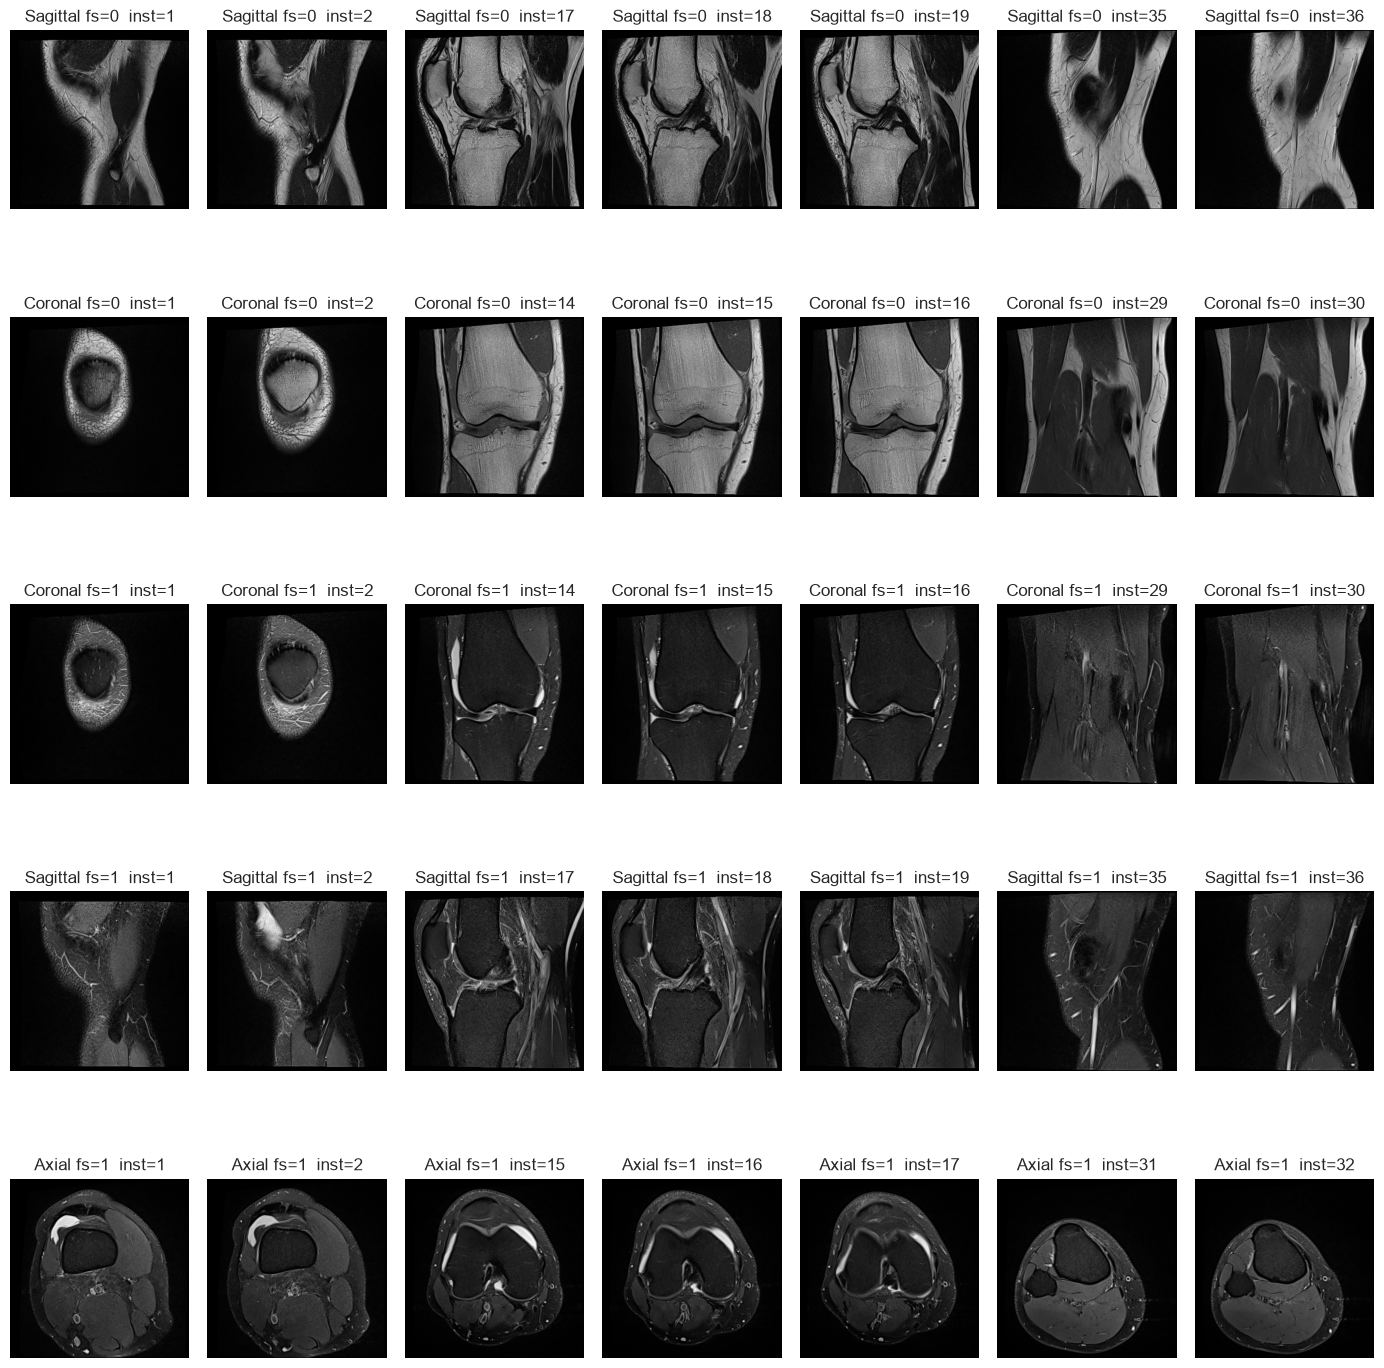

In [212]:
# One figure: rows = series; cols = first 2, middle 3, last 2 (by InstanceNumber).
n_head, n_mid, n_tail = 2, 3, 2
n_cols = n_head + n_mid + n_tail

def pick_preview_slices(group):
    g = group.sort_values("InstanceNumber").reset_index(drop=True)
    n = len(g)
    mid_start = max(0, (n - n_mid) // 2)
    idx = (
        list(range(min(n_head, n)))
        + list(range(mid_start, min(mid_start + n_mid, n)))
        + list(range(max(0, n - n_tail), n))
    )
    seen, ordered = set(), []
    for i in idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)
    return g.iloc[ordered]

preview_parts = []
for _, group in slice_meta.groupby("SeriesInstanceUID"):
    preview_parts.append(pick_preview_slices(group))
preview = pd.concat(preview_parts, ignore_index=True).merge(
    train_series[["SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]],
    on="SeriesInstanceUID",
    how="left",
)

series_ids = list(preview["SeriesInstanceUID"].unique())
n_series = len(series_ids)
fig, axes = plt.subplots(n_series, n_cols, figsize=(14, 3 * n_series), squeeze=False)

for row_idx, series_id in enumerate(series_ids):
    series_slices = preview.loc[preview["SeriesInstanceUID"] == series_id]
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        if col_idx >= len(series_slices):
            ax.axis("off")
            continue
        slice_row = series_slices.iloc[col_idx]
        ds = pydicom.dcmread(slice_row["path"])
        pixels = ds.pixel_array
        ax.imshow(pixels, cmap="gray", vmin=int(pixels.min()), vmax=int(pixels.max()))
        ax.axis("off")
        ax.set_title(
            f"{slice_row['Anatomical_Plane']} fs={int(slice_row['Fluid_Sensitive'])}  "
            f"inst={int(slice_row['InstanceNumber'])}"
        )

fig.tight_layout()
plt.show()


Findings:
- mris within a series are sequenctial scans along an axis of the knee